In [ ]:
import xscen as xs
import xarray as xr
import figanos.matplotlib as fg
import xclim as xc
import glob
import pandas as pd
import numpy as np
from xscen import CONFIG
from pathlib import Path
from matplotlib import pyplot as plt

pd.set_option('display.max_rows', None)
xs.load_config("../config/config_ESPO.yml",  "../config/paths_ESPO.yml", reset=True)

cat = xs.DataCatalog(CONFIG['extraction']['simulation']['search_data_catalogs']['data_catalogs'][0])


# Inputs

## availability

In [ ]:
# need
# pip install PyQt5-sip
# pip install --no-index ete3 PyQt5

import os
os.environ["QT_QPA_PLATFORM"] = "offscreen"  # prevent Qt kernel crash in Jupyter

import numpy as np
import itertools
import pandas as pd
from ete3 import Tree, TreeStyle, NodeStyle, TextFace, add_face_to_node
import xscen as xs
from IPython.display import Image, display

# ── 1. Data─────────────────────────

# cat_sim_id = xs.search_data_catalogs(**{'variables_and_freqs': {'tasmax': 'D',
#   'tasmin': 'D',
#   'pr': 'D',
#   'dtr': 'D',
#   'sftlf': 'fx'},
#  'match_hist_and_fut': True,
#  'allow_conversion': True,
#  'allow_resampling': False,
#  'periods': ['1951', '2100'],
#  'exclusions': {
#      'id':['CMIP6_ScenarioMIP_CCCma_CanESM5_ssp245_r1i1p1f1_global', #To only have 5 members
#           'CMIP6_ScenarioMIP_CCCma_CanESM5_ssp370_r1i1p1f1_global',
#           'CMIP6_ScenarioMIP_CCCma_CanESM5_ssp585_r1i1p1f1_global',
#         'CMIP6_ScenarioMIP_CCCma_CanESM5_ssp245_r2i1p2f1_global',
#           'CMIP6_ScenarioMIP_CCCma_CanESM5_ssp370_r2i1p2f1_global',
#           'CMIP6_ScenarioMIP_CCCma_CanESM5_ssp585_r2i1p2f1_global',
#            'CMIP6_ScenarioMIP_EC-Earth-Consortium_EC-Earth3_ssp245_r10i1p1f1_global',
#           ],
#   'source': ['GFDL-CM4', 'EC-Earth3-CC','KIOST-ESM','NESM3']},
#  'other_search_criteria': {'processing_level': 'raw',
#   'mip_era': 'CMIP6',
#   'experiment': ['ssp245', 'ssp370', 'ssp585']},
#  'data_catalogs': CONFIG['extraction']['simulation']['search_data_catalogs']['data_catalogs']},)
cat_sim_id= xs.search_data_catalogs(**CONFIG["extraction"]["simulation"]["search_data_catalogs"])
df=pd.concat([cat.df for cat in cat_sim_id.values()])



df=df[['source', 'member', 'experiment', 'driving_model',"driving_member" ]].drop_duplicates()
df["driving_model"] = df["driving_model"].fillna(df["source"])
df["driving_member"] = df["driving_member"].fillna(df["member"])
df.loc[df["driving_model"] == df["source"], "source"] = 'G'

# ── 2. Build the ete3 Tree from the DataFrame ─────────────────────────────────

def build_tree(df: pd.DataFrame) -> Tree:
    """
    Build a 3-level tree: experiment → member → source
    """
    root = Tree()
    root.name = "root"

    for experiment, exp_group in df.groupby("experiment"):
        exp_node = root.add_child(name=str(experiment))
 
        for source, source_group in exp_group.groupby("driving_model"):
            source_node = exp_node.add_child(name=str(source))
 
            for member, member_group in source_group.groupby("driving_member"):
                member_node = source_node.add_child(name=str(member))
            
                    
                for rcm, rcm_group in member_group.groupby("source"):
                    rcm_node = member_node.add_child(name=str(rcm))

    return root


tree = build_tree(df)


# ── 3. Style nodes by level ───────────────────────────────────────────────────

LEVEL_COLORS = {
    0: "#2c3e50" ,   # root
    1: "#052946",   # experiment
    2: "#18BBBB",   # member
    3: "#CE153D",   # source
    4: "#FDC414",   # rcm
}


def style_tree(tree: Tree) -> None:
    """Apply visual styles — no circle markers, leaf count on experiment nodes."""
    for node in tree.traverse():
        depth = node.get_distance(tree, topology_only=True)
        level = int(depth)
        color = LEVEL_COLORS.get(level, LEVEL_COLORS[3])

        # Remove all circle markers
        ns = NodeStyle()
        ns["size"] = 0
        ns["vt_line_color"] = "#95a5a6"
        ns["hz_line_color"] = "#95a5a6"
        ns["vt_line_width"] = 1.5
        ns["hz_line_width"] = 1.5
        node.set_style(ns)

        if node.is_root():
            continue

        # Experiment nodes: name + number of leaves
        if level == 1:
            n_leaves = len(node.get_leaves())
            n_children = len(node.get_children())
            label = TextFace(
                f" {node.name} \n  ({n_children},{n_leaves})",
                fsize=9,
                fgcolor=color,
                bold=True,
            )
            node.add_face(label, column=0, position="branch-right")

        # Member and source nodes: name only
        else:
            label = TextFace(
                f" {node.name}",
                fsize=7,
                fgcolor=color,
                bold=(level == 2),
            )
            node.add_face(label, column=0, position="branch-right")


style_tree(tree)


# ── 4. Configure circular TreeStyle ──────────────────────────────────────────

ts = TreeStyle()
ts.show_leaf_name = False
ts.show_branch_length = False
ts.show_branch_support = False
ts.mode = "c"
ts.arc_start = -180
ts.arc_span  = 360
ts.show_scale = False

ts.title.add_face(
    TextFace("Available on narval", fsize=14, bold=True),
    column=0,
)
#to avoid bug on narval
for node in tree.traverse():
    node.img_style["hz_line_width"]=1
    node.img_style["vt_line_width"]=1

# ── 5. Render ─────────────────────────────────────────────────────────────────

OUTPUT_FILE = "tree_of_inputs.png"
tree.render(OUTPUT_FILE, tree_style=ts, w=1400, units="px", dpi=150)

display(Image(OUTPUT_FILE))


## Inputs Health Checks

In [42]:
print('QC')
for f in np.sort(glob.glob(f'{CONFIG['paths']['final']}/inputchecks/QC/*')):
    ds=xr.open_zarr(f)
    for var in ds.data_vars:
        if bool(ds[var].values) is not False:
            # very small negative values are fine
            if var == 'pr_negative_accumulation_values' and ds[var].values>-1e-4:
                break
            print(ds.attrs['cat:id'])
            print(var, ds[var].values)
print('NAM')
for f in np.sort(glob.glob(f'{CONFIG['paths']['final']}/inputchecks/NAM/*')):
    ds=xr.open_zarr(f)
    for var in ds.data_vars:
        if bool(ds[var].values) is not False:
            # very small negative values are fine
            if var == 'pr_negative_accumulation_values' and ds[var].values>-1e-4: 
                break
            print(ds.attrs['cat:id'])
            print(var, ds[var].values)

QC
NAM
CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12
pr_very_large_precipitation_events 1685.5224609375
CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp585_r1_NAM-12
pr_very_large_precipitation_events 1738.5864257812502
CMIP6_CORDEX_MPI-ESM1-2-LR_r3i1p1f1_OURANOS_CRCM5-SN_ssp370_r1_NAM-12
pr_very_large_precipitation_events 2001.26953125
CMIP6_ScenarioMIP_CSIRO-ARCCSS_ACCESS-CM2_ssp245_r5i1p1f1_global
pr_very_large_precipitation_events 1667.1701967716217
CMIP6_ScenarioMIP_CSIRO-ARCCSS_ACCESS-CM2_ssp370_r1i1p1f1_global
pr_very_large_precipitation_events 1918.445760011673
CMIP6_ScenarioMIP_CSIRO-ARCCSS_ACCESS-CM2_ssp370_r2i1p1f1_global
pr_very_large_precipitation_events 2321.8511760234833
CMIP6_ScenarioMIP_CSIRO-ARCCSS_ACCESS-CM2_ssp370_r4i1p1f1_global
pr_very_large_precipitation_events 1833.6767971515656
CMIP6_ScenarioMIP_CSIRO-ARCCSS_ACCESS-CM2_ssp370_r5i1p1f1_global
pr_very_large_precipitation_events 1811.0400259494781
CMIP6_ScenarioMIP_CSIRO-ARCCSS_ACCESS-CM2_ssp58

## Inputs Warnings

/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/plot.py:361: UserWarning: CFTimeIndex converted to pandas DatetimeIndex with a 'standard' calendar.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/pro

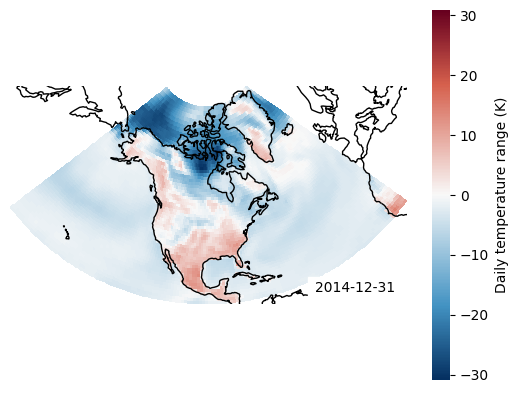

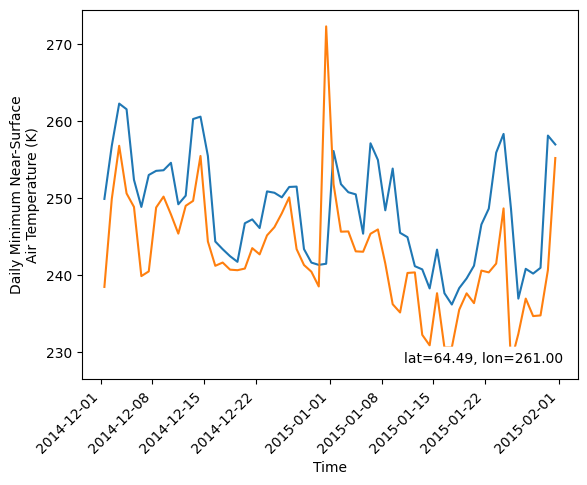

In [26]:
ds=cat_sim_id['CMIP6_ScenarioMIP_BCC_BCC-CSM2-MR_ssp245_r1i1p1f1_global'].search(xrfreq='D').to_dataset(xarray_open_kwargs={'engine':'h5netcdf'})
ds=xs.spatial.subset(ds, method='bbox',   lon_bnds= [ -179.95, -10 ],lat_bnds= [ 12.5, 83.4 ],)
ds['dtr']= ds['tasmax']-ds['tasmin']
ds['dtr'].attrs['long_name']='Daily temperature range'
fg.gridmap(ds.sel(time='2014-12-31').dtr, features=['coastline'], cmap='temp_div', show_time=True)
ax=fg.timeseries(ds.sel(lat=64.485399, lon=261, method='nearest').sel( time=slice('2014-12', '2015-01')).tasmax,)
fg.timeseries(ds.sel(lat=64.485399, lon=261, method='nearest').sel( time=slice('2014-12', '2015-01')).tasmin, ax=ax)
plt.xticks(rotation=45, ha='right');
#  On 2014-12-31, there are many large negative values of dtr. Every grid points on that day was set to nan for dtr and tasmin. The workflow will fill the nans with interpolation over the time dimension.

/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.


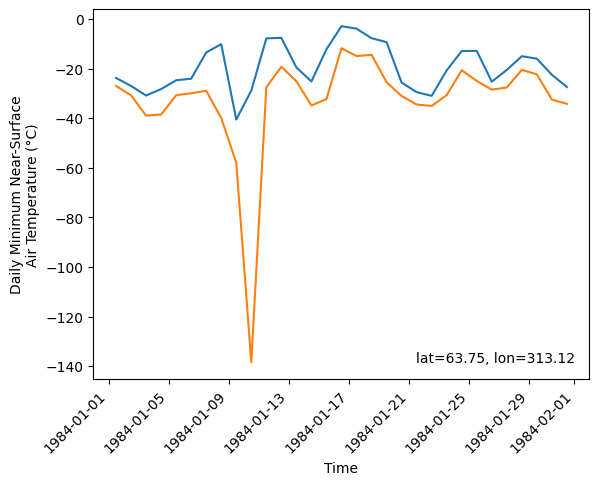

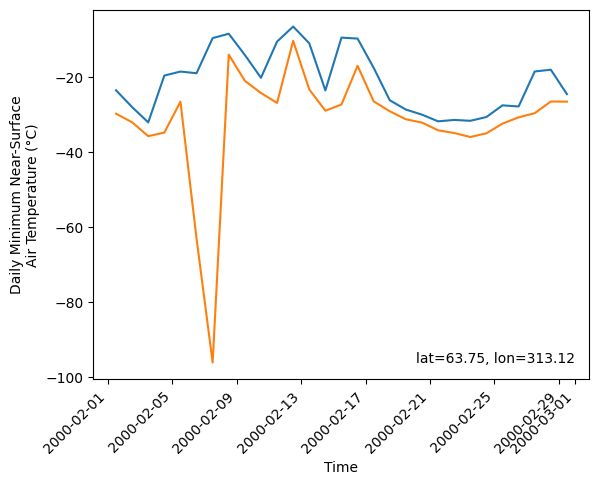

In [30]:
ds=cat_sim_id['CMIP6_ScenarioMIP_CSIRO_ACCESS-ESM1-5_ssp245_r1i1p1f1_global'].search(xrfreq='D').to_dataset(xarray_open_kwargs={'engine':'h5netcdf'})
ds['tasmax']=xc.core.units.convert_units_to(ds['tasmax'], 'degC')
ds['tasmin']=xc.core.units.convert_units_to(ds['tasmin'], 'degC')
ax=fg.timeseries(ds.sel(lat=63.75, lon=313.125, method='nearest').sel( time='1984-01').tasmax,)
fg.timeseries(ds.sel(lat=63.75, lon=313.125, method='nearest').sel( time='1984-01').tasmin, ax=ax)
plt.xticks(rotation=45, ha='right')

ax=fg.timeseries(ds.sel(lat=63.75, lon=313.125, method='nearest').sel( time='2000-02').tasmax,)
fg.timeseries(ds.sel(lat=63.75, lon=313.125, method='nearest').sel( time='2000-02').tasmin, ax=ax)
plt.xticks(rotation=45, ha='right');
#On 1984-01-10 and 2000-02-07, at 63.75N; 313.125E, tasmin is -138 K. This single gridpoint was replaced by a nan. The workflow will fill the nan with interpolation over the time dimension.

/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/intake_esm/source.py:272: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/plot.py:361: UserWarning: CFTimeIndex converted to pandas DatetimeIndex with a 'standard' calendar.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.


<GeoAxes: xlabel='Longitude [degrees_east]', ylabel='Latitude [degrees_north]'>

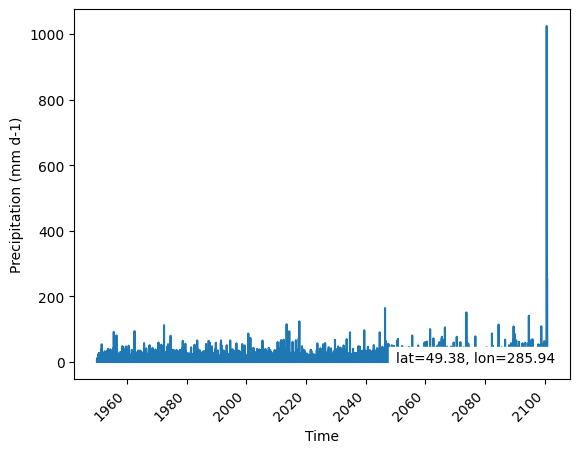

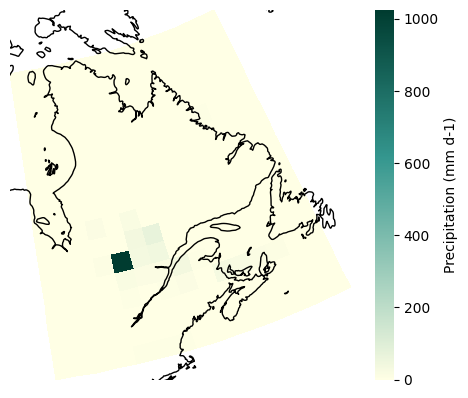

In [36]:
ds=cat_sim_id['CMIP6_ScenarioMIP_MOHC_UKESM1-0-LL_ssp370_r1i1p1f2_global'].search(xrfreq='D').to_dataset(xarray_open_kwargs={'engine':'h5netcdf'})
ds['pr']=xc.core.units.convert_units_to(ds['pr'], 'mm/day', context='hydro')
ds=xs.spatial.subset(ds, method='bbox',   lon_bnds= [ -83, -55 ],lat_bnds= [ 42, 63 ],)
ax=fg.timeseries(ds.sel(lat=49.375, lon=285.9375, method='nearest').pr,)
plt.xticks(rotation=45, ha='right');

fg.gridmap(ds.pr.sel(time='2100-08-11'), features=['coastline'])
#On 2100-08-11, at 49.375N; 285.9375E, there is a single gridpoint (over Québec) with precipitation of 1024 mm/day. This gridpoint was replaced by the mean of its eight spatial neighbors.

# Outputs

## Outputs health checks

In [43]:
print('QC')
for f in np.sort(glob.glob(f'{CONFIG['paths']['final']}/checks/QC/*')):
    ds=xr.open_zarr(f)
    for var in ds.data_vars:
        if bool(ds[var].values) is not False:
            # very small negative values are fine
            if var == 'pr_negative_accumulation_values' and ds[var].values>-1e-4:
                break
            print(ds.attrs['cat:id'])
            print(var, ds[var].values)
print('NAM')
for f in np.sort(glob.glob(f'{CONFIG['paths']['final']}/checks/NAM/*')):
    ds=xr.open_zarr(f)
    for var in ds.data_vars:
        if bool(ds[var].values) is not False:
            # very small negative values are fine
            if var == 'pr_negative_accumulation_values' and ds[var].values>-1e-4: 
                break
            print(ds.attrs['cat:id'])
            print(var, ds[var].values)

QC
ESPO_CaSR_CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp585_r1_NAM
pr_very_large_precipitation_events True
NAM
ESPO_CaSR_CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp585_r1_NAM
tasmin_temperature_extremely_low True


2026-06-22 21:27:08 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


INFO:xscen.spatial:Loading longitude for more efficient subsetting.


2026-06-22 21:27:08 INFO     xscen.spatial   Loading latitude for more efficient subsetting.


INFO:xscen.spatial:Loading latitude for more efficient subsetting.


[-71.29083]


...

2026-06-22 21:27:17 INFO     xscen.spatial   Loading latitude for more efficient subsetting.


INFO:xscen.spatial:Loading latitude for more efficient subsetting.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/plot.py:361: UserWarning: CFTimeIndex converted to pandas DatetimeIndex with a 'standard' calendar.


[-75.493744]


/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.


<Axes: xlabel='Time', ylabel='Daily Minimum Near-Surface\nAir Temperature (°C)'>

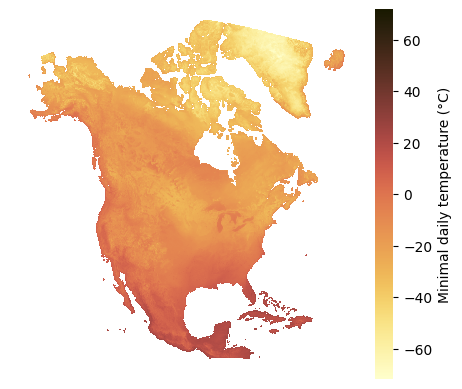

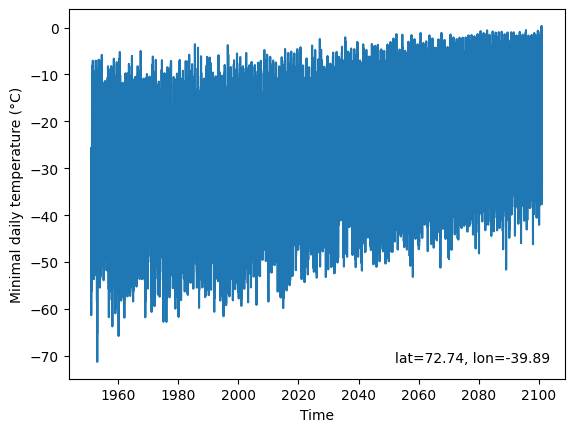

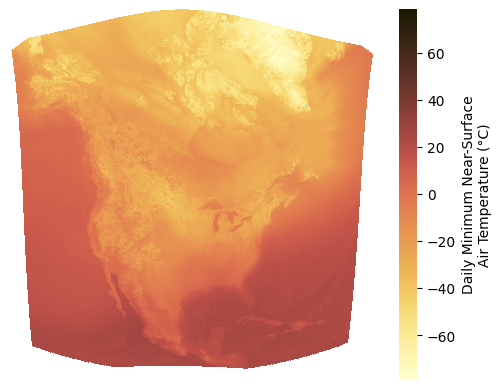

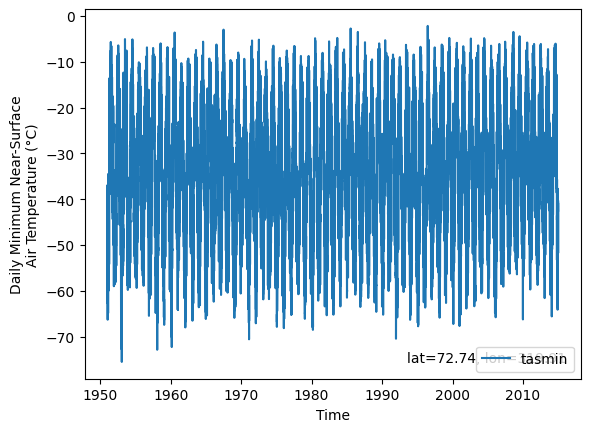

In [5]:
ds= xr.open_zarr(f"{CONFIG['paths']['final']}/staging/simulation/biasadjusted/ESPO_v20_CaSR/CMIP6/CORDEX/NAM/OURANOS/CRCM5-SN/CanESM5/r1i1p2f1/ssp585/r1/day/tasmin/tasmin_day_ESPO6_v20_CaSR+CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp585_r1_NAM-12_NAM_1951-2100.zarr.zip")
ds['tasmin']=xc.core.units.convert_units_to(ds.tasmin, 'degC')
ds=xs.spatial.subset(ds, method='bbox',   lon_bnds= [ -179.95, -10 ],lat_bnds= [ 12.5, 83.4 ],)
print(ds.tasmin.sel(time='1953-01-21', rlat=20.43, rlon=14.55278).values)
#print(ds.sel(rlat=20.43, rlon=14.55278).lat.values,ds.sel(rlat=20.43, rlon=14.55278).lon.values)
fg.gridmap(ds.tasmin.sel(time='1953-01-21'))
fg.timeseries(ds.tasmin.sel(rlat=20.43, rlon=14.55278))

ds=cat.search(id='CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_historical_r1_NAM-12', variable='tasmin', xrfreq='D').to_dataset(xarray_open_kwargs={'engine':'h5netcdf'})
ds['tasmin']=xc.core.units.convert_units_to(ds.tasmin, 'degC')
ds=xs.spatial.subset(ds, method='bbox',   lon_bnds= [ -179.95, -10 ],lat_bnds= [ 12.5, 83.4 ],)
fg.gridmap(ds.tasmin.sel(time='1953-01-21'))
print(xs.spatial.subset(ds.sel(time='1953-01-21'), method='gridpoint', lat=72.73723, lon=-39.891663).tasmin.values)
fg.timeseries(xs.spatial.subset(ds, method='gridpoint', lat=72.73723, lon=-39.891663))

2026-06-25 08:36:03 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


INFO:xscen.spatial:Loading longitude for more efficient subsetting.


2026-06-25 08:36:03 INFO     xscen.spatial   Loading latitude for more efficient subsetting.


INFO:xscen.spatial:Loading latitude for more efficient subsetting.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.


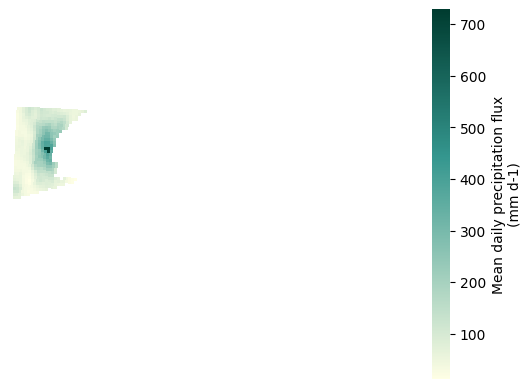

In [21]:
ds= xr.open_zarr(f"{CONFIG['paths']['final']}/staging/simulation/biasadjusted/ESPO_v20_CaSR/CMIP6/CORDEX/NAM/OURANOS/CRCM5-SN/CanESM5/r1i1p2f1/ssp585/r1/day/pr/pr_day_ESPO6_v20_CaSR+CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp585_r1_NAM-12_NAM_1951-2100.zarr.zip")
ds=xs.spatial.subset(ds, method='bbox',   lon_bnds= [ -83, -55 ],lat_bnds= [ 42, 63 ],)

#ds.where((ds.pr==ds.pr.max().values).compute(),drop=True)
ds['pr']=xc.core.units.convert_units_to(ds['pr'], 'mm/day', context='hydro')
ax=fg.gridmap(ds.pr.isel(rlat=slice(None, 50), rlon=slice(120, None)).sel(time='2097-08-05'))


2026-06-25 08:39:17 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


INFO:xscen.spatial:Loading longitude for more efficient subsetting.


2026-06-25 08:39:17 INFO     xscen.spatial   Loading latitude for more efficient subsetting.


INFO:xscen.spatial:Loading latitude for more efficient subsetting.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/plot.py:361: UserWarning: CFTimeIndex converted to pandas DatetimeIndex with a 'standard' calendar.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.


43.21009 -70.6138
2026-06-25 08:39:20 INFO     xscen.spatial   Loading longitude for more efficient subsetting.


INFO:xscen.spatial:Loading longitude for more efficient subsetting.


2026-06-25 08:39:20 INFO     xscen.spatial   Loading latitude for more efficient subsetting.


INFO:xscen.spatial:Loading latitude for more efficient subsetting.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/plot.py:361: UserWarning: CFTimeIndex converted to pandas DatetimeIndex with a 'standard' calendar.
/lustre06/project/6046550/julavoie/envs/espov2/lib/python3.12/site-packages/figanos/matplotlib/utils.py:287: UserWarning: Attribute "description" not found.


Text(0.5, 1.0, 'raw')

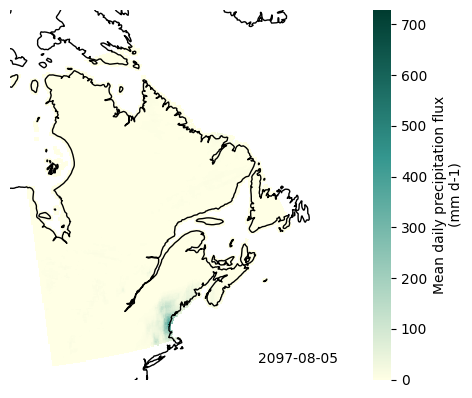

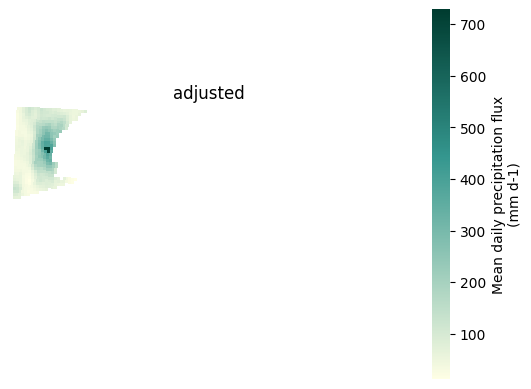

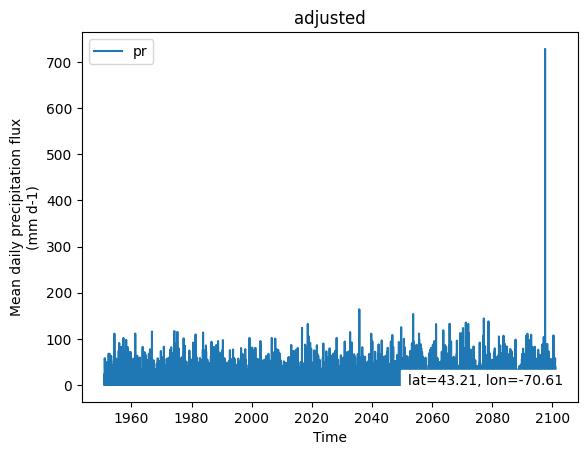

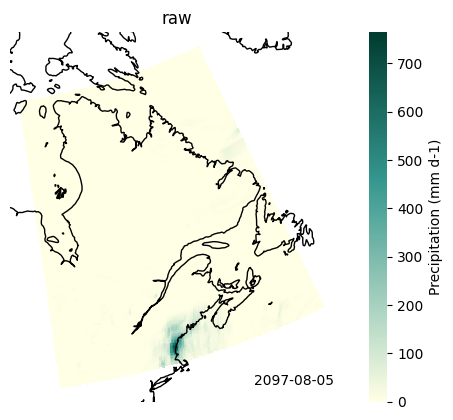

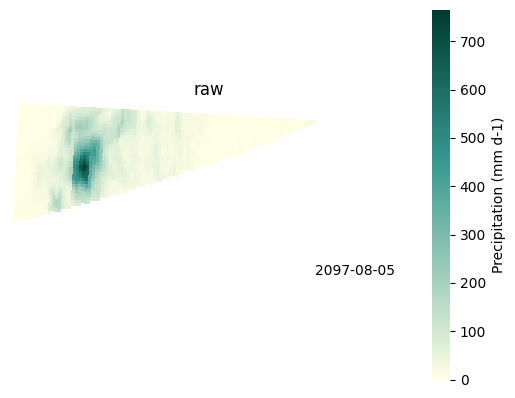

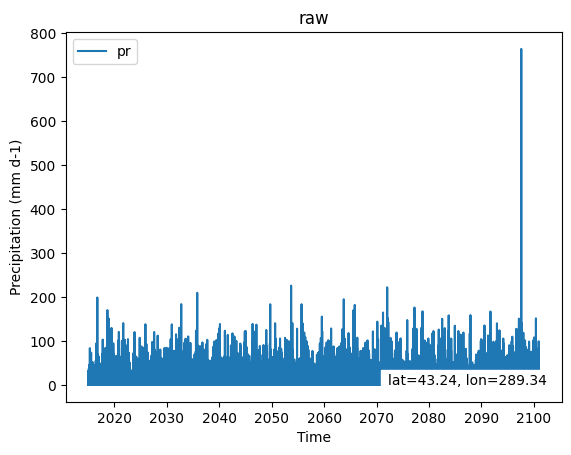

In [27]:
ds= xr.open_zarr(f"{CONFIG['paths']['final']}/staging/simulation/biasadjusted/ESPO_v20_CaSR/CMIP6/CORDEX/NAM/OURANOS/CRCM5-SN/CanESM5/r1i1p2f1/ssp585/r1/day/pr/pr_day_ESPO6_v20_CaSR+CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp585_r1_NAM-12_NAM_1951-2100.zarr.zip")
ds=xs.spatial.subset(ds, method='bbox',   lon_bnds= [ -83, -55 ],lat_bnds= [ 42, 63 ],)

#ds.where((ds.pr==ds.pr.max().values).compute(),drop=True)
ds['pr']=xc.core.units.convert_units_to(ds['pr'], 'mm/day', context='hydro')
ax=fg.gridmap(ds.pr.sel(time='2097-08-05'), features=['coastline'], show_time=True)
ax=fg.gridmap(ds.pr.isel(rlat=slice(None, 50), rlon=slice(120, None)).sel(time='2097-08-05'))
ax.set_title('adjusted')
ax=fg.timeseries(ds.sel(rlat=-12.42, rlon=16.082779))
ax.set_title('adjusted')
print(ds.sel(rlat=-12.42, rlon=16.082779).lat.values,ds.sel(rlat=-12.42, rlon=16.082779).lon.values,)


ds=cat.search(id='CMIP6_CORDEX_CanESM5_r1i1p2f1_OURANOS_CRCM5-SN_ssp585_r1_NAM-12', variable='pr', xrfreq='D').to_dataset(xarray_open_kwargs={'engine':'h5netcdf'})
ds=xs.spatial.subset(ds, method='bbox',   lon_bnds= [ -83, -55 ],lat_bnds= [ 42, 63 ],)
ds['pr']=xc.core.units.convert_units_to(ds['pr'], 'mm/day', context='hydro')
ax=fg.gridmap(ds.pr.sel(time='2097-08-05'), features=['coastline'], show_time=True)
ax.set_title('raw')
ax=fg.gridmap(ds.pr.sel(time='2097-08-05').isel(rlat=slice(None, 50), rlon=slice(90, None)), show_time=True)
ax.set_title('raw')
ax=fg.timeseries(xs.spatial.subset(ds=ds, method='gridpoint', lat=43.21009, lon=-70.6138))
ax.set_title('raw')